# Recap!!

We learned embeddings using the Word2Vec model, understood the notion of embedding vectors for individual words, and calculated the similarity of (dis)similar words. On visualizing the word embedding vectors in a low-dimensional space, we observed words belonging to the same concept are embedded close to each other.

### Imports and logging

First, we start with our imports and get logging established:

In [1]:
import gensim 
import numpy as np
import pandas as pd

### Dataset 
Next, is our dataset. The secret to getting Word2Vec to work is to have lots and lots of text data. We are using the Amazon review dataset, where we have customer reviews and their respective sentiment (i.e., positive or negative).

We can pass the text as a sequence of sentences to Gensim or directly pass the whole text as a single string.

Gensim: https://radimrehurek.com/gensim/index.html

Reference: https://www.kaggle.com/code/pranavjha24/amazon-reviews-word2vec-gensim
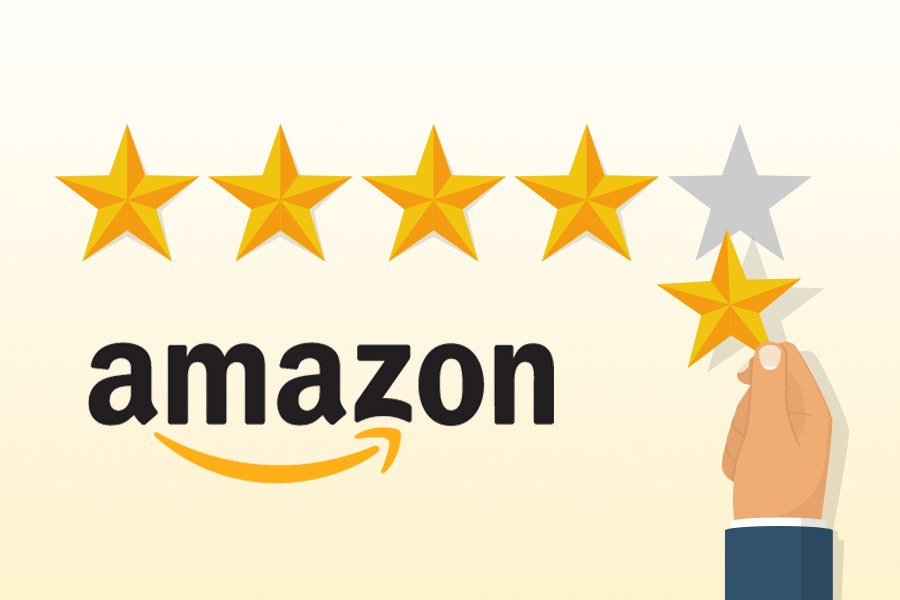

In [2]:
df = pd.read_json("./data/reviews_Cell_Phones_and_Accessories_5.json", lines=True)
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A30TL5EWN6DFXT,120401325X,christina,"[0, 0]",They look good and stick good! I just don't li...,4,Looks Good,1400630400,"05 21, 2014"
1,ASY55RVNIL0UD,120401325X,emily l.,"[0, 0]",These stickers work like the review says they ...,5,Really great product.,1389657600,"01 14, 2014"
2,A2TMXE2AFO7ONB,120401325X,Erica,"[0, 0]",These are awesome and make my phone look so st...,5,LOVE LOVE LOVE,1403740800,"06 26, 2014"
3,AWJ0WZQYMYFQ4,120401325X,JM,"[4, 4]",Item arrived in great time and was in perfect ...,4,Cute!,1382313600,"10 21, 2013"
4,ATX7CZYFXI1KW,120401325X,patrice m rogoza,"[2, 3]","awesome! stays on, and looks great. can be use...",5,leopard home button sticker for iphone 4s,1359849600,"02 3, 2013"


In [3]:
df.shape

(194439, 9)

### Simple Preprocessing and Tokenization
The first thing to do for any data science task is to clean the data. For NLP, we apply various processing steps, such as:

1. Converting all words to lowercase
2. Trimming spaces
3. Removing punctuations

Additionally, we can also:

1. Remove stop words like 'and', 'or', 'is', 'the', 'a', 'an'
2. Convert words to their root forms, like changing 'running' to 'run'

This is something we will do over here.

In [4]:
review_text = df.reviewText.apply(gensim.utils.simple_preprocess)
review_text

0         [they, look, good, and, stick, good, just, don...
1         [these, stickers, work, like, the, review, say...
2         [these, are, awesome, and, make, my, phone, lo...
3         [item, arrived, in, great, time, and, was, in,...
4         [awesome, stays, on, and, looks, great, can, b...
                                ...                        
194434    [works, great, just, like, my, original, one, ...
194435    [great, product, great, packaging, high, quali...
194436    [this, is, great, cable, just, as, good, as, t...
194437    [really, like, it, becasue, it, works, well, w...
194438    [product, as, described, have, wasted, lot, of...
Name: reviewText, Length: 194439, dtype: object

## Training the Word2Vec model

Training the model is fairly straightforward. You just instantiate Word2Vec and pass the reviews that we read in the previous step (the `documents`). So, we are essentially passing on a list of lists. Where each list within the main list contains a set of tokens from a user review. Word2Vec uses all these tokens to internally create a vocabulary. And by vocabulary, I mean a set of unique words.

Behind the scenes we are actually training a simple neural network with a single hidden layer. But, we are actually not going to use the neural network after training. Instead, the goal is to learn the weights of the hidden layer. These weights are essentially the word vectors that we’re trying to learn. 

In [5]:
# Initialize Word2Vec model
model = gensim.models.Word2Vec(review_text, vector_size=32, window=10, min_count=2, workers=10)

# Build Vocabulary
model.build_vocab(review_text, progress_per=1000)

# Train the Word2Vec Model
model.train(review_text, total_examples=model.corpus_count, epochs=model.epochs)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

(61508986, 83868975)

## Now, let's look at some output 
This first example shows a simple case of looking up `good` review. We simply have to call the `most_similar` function and provide the word `good` as the positive example. This returns the top 10 similar words. 

In [6]:
w1 = "good"
model.wv.most_similar(positive=w1, topn=10)

[('decent', 0.8925846219062805),
 ('great', 0.8463554382324219),
 ('fantastic', 0.7878468036651611),
 ('reasonable', 0.7818155884742737),
 ('excellent', 0.7555674910545349),
 ('amazing', 0.7546056509017944),
 ('nice', 0.7489657402038574),
 ('awesome', 0.7470333576202393),
 ('wonderful', 0.7239550948143005),
 ('perfect', 0.715463399887085)]

That looks pretty good, right? Let's look at a few more. Let's look at similarity for `bad`, `cheap` and `inexpensive`. 

In [7]:
# look up top 6 words similar to 'ron'
w1 = ["bad"]
model.wv.most_similar (positive=w1,topn=6)


[('okay', 0.7637893557548523),
 ('ok', 0.7472062110900879),
 ('horrible', 0.7422741651535034),
 ('concerned', 0.7308220267295837),
 ('sad', 0.7120627760887146),
 ('terrible', 0.7071102261543274)]

In [8]:
# look up top 6 words similar to 'hermione'
w1 = ["cheap"]
model.wv.most_similar (positive=w1,topn=6)


[('cheep', 0.7785183191299438),
 ('flimsy', 0.7540871500968933),
 ('alright', 0.714845597743988),
 ('cheaply', 0.6868546605110168),
 ('brittle', 0.6636039614677429),
 ('okay', 0.6515278220176697)]

In [9]:
# look up top 6 words similar to 'voldemort'
w1 = ["inexpensive"]
model.wv.most_similar (positive=w1,topn=6)


[('affordable', 0.8195191025733948),
 ('effective', 0.7136383652687073),
 ('reasonable', 0.6982978582382202),
 ('bargain', 0.6604599952697754),
 ('good', 0.6459721922874451),
 ('attractive', 0.6365165710449219)]

## Let's visualize the entire vocabulary using the learned embeddings

We will first extract the vectors of all the words in our vocabulary and store them in one place for easy access.

In [10]:
# Get the ordered list of words in the vocabulary
words = list(w for w in model.wv.index_to_key)

# extract all vectors
embedding = []
for w in words[:500]:
    embedding.append(model.wv[w])
    
# Visualize word2vec Embeddings
import pandas
import umap.umap_ as umap
import plotly.express as px
import matplotlib.pyplot as plt

cluster_embedding = umap.UMAP(n_neighbors=100, min_dist=0.0,
                              n_components=2, random_state=42).fit_transform(embedding)

fig = px.scatter(x=cluster_embedding[:, 0], y=cluster_embedding[:, 1], color=words[:500])
fig.show()

/opt/anaconda3/envs/ds6051/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Next, let's use Word2Vec to generate embeddings for a product review dataset and train a sentiment classifier on it!!

In [11]:
# Creating the dataset using Word2Vec
X, y = [], []
for ind in range(review_text.shape[0]):
    X_interim = []
    if review_text[ind] != []:
        for word in review_text[ind]:
            if word in model.wv:
                X_interim.append(model.wv[word])
        if X_interim == []:
            print(ind)
            break
        X.append(np.mean(X_interim, axis=0))
        if df.iloc[ind]['overall'] >= 3:
            y.append(1)
        else:
            y.append(0)

# Convert to arrays
X = np.array(X)
y = np.array(y)

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Evaluation function
def evaluate(y_true, y_pred, y_prob):
    # Making the Confusion Matrix
    from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
    cm = confusion_matrix(y_true, y_pred)
    acc_score = accuracy_score(y_true, y_pred)
    roc_score = roc_auc_score(y_true, y_prob)
    return cm, acc_score, roc_score

76758


### Fitting Logistic Regression to the Training set

Accuracy score: 0.86
ROC Accuracy score: 0.84


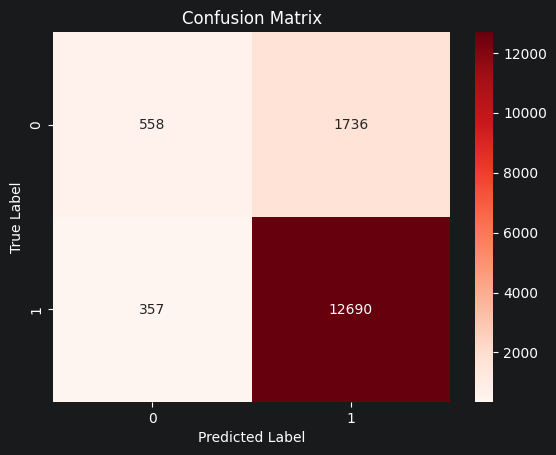

In [12]:
import seaborn as sns
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=42).fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)

result = evaluate(y_test, y_pred, y_prob[:, 1])
print(f'Accuracy score: {result[1]:.2f}')
print(f'ROC Accuracy score: {result[2]:.2f}')

# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap using seaborn
sns.heatmap(result[0], annot=True, fmt='d', cmap='Reds', ax=ax)

# Set the labels
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')

# Show the plot
plt.show()

### Fitting Neural Network to the Training set

Accuracy score: 0.87


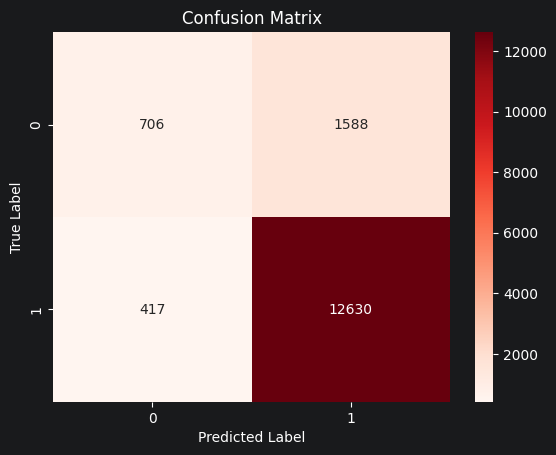

In [13]:
import seaborn as sns
from sklearn.neural_network import MLPClassifier

classifier = MLPClassifier(hidden_layer_sizes=(16, 2), random_state=42)

classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)

result = evaluate(y_test, y_pred, y_prob[:, 1])
print(f'Accuracy score: {result[1]:.2f}')

# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap using seaborn
sns.heatmap(result[0], annot=True, fmt='d', cmap='Reds', ax=ax)

# Set the labels
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')

# Show the plot
plt.show()

### What happens if we scale the size of the neural network

Accuracy score: 0.87


/opt/anaconda3/envs/ds6051/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


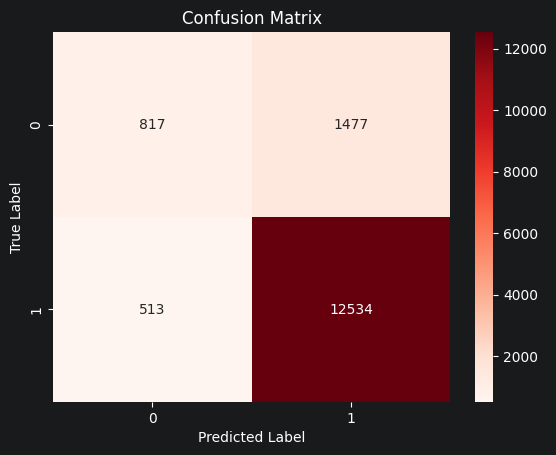

In [14]:
classifier = MLPClassifier(hidden_layer_sizes=(32, 2), random_state=42)

classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)

result = evaluate(y_test, y_pred, y_prob[:, 1])
print(f'Accuracy score: {result[1]:.2f}')

# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap using seaborn
sns.heatmap(result[0], annot=True, fmt='d', cmap='Reds', ax=ax)

# Set the labels
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')

# Show the plot
plt.show()

### And that's a wrap on training a Sentiment Classifier!!